In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.feature_selection import mutual_info_classif

In [2]:
train = pd.read_csv('data/train.csv')

In [3]:
train

,policy_id,insured_id,snapshot_date,policy_effective_date,policy_expiration_date,coverage_type,vehicle_count,vehicle_avg_age,driver_count,driver_avg_age,...,risk_score_external,has_safety_program,num_heavy_vehicles,late_payment_count,claim_count,total_loss_amount,first_claim_reported_date,claim_paid_amount_current_period,claim_status_current_period,days_to_first_claim_report
0,POL-006680,INS-00529,2021-07-24,2021-05-26,2022-05-26,APD,7,5.9,8,47.5,...,83.06,0,0,1.0,0,0.0,NaN,0.00,No Claim,NaN
1,POL-003291,INS-02313,2021-03-17,2020-11-26,2021-11-26,APD,6,6.0,6,32.5,...,82.16,0,2,3.0,0,0.0,NaN,0.00,No Claim,NaN
2,POL-006559,INS-02723,2022-11-10,2022-05-17,2023-05-17,APD,6,4.1,5,40.9,...,77.75,1,0,0.0,0,0.0,NaN,0.00,No Claim,NaN
3,POL-007927,INS-03739,2021-03-12,2020-10-20,2021-10-20,AL,14,6.0,9,47.5,...,43.60,1,3,0.0,0,0.0,NaN,0.00,No Claim,NaN
4,POL-005665,INS-00218,2021-08-21,2021-05-04,2022-05-04,APD,7,2.5,2,48.1,...,13.20,1,0,0.0,0,0.0,NaN,0.00,No Claim,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15070,POL-005192,INS-00229,2022-09-27,2022-06-05,2023-06-05,APD,9,4.0,7,39.2,...,NaN,1,1,0.0,0,0.0,NaN,0.00,No Claim,NaN
15071,POL-013419,INS-03560,2021-10-06,2021-09-14,2022-09-14,AL,8,0.3,9,38.9,...,NaN,1,2,3.0,0,0.0,NaN,0.00,No Claim,NaN
15072,POL-005391,INS-02372,2020-07-15,2020-07-12,2021-07-12,APD,9,5.8,6,44.2,...,96.22,0,2,3.0,1,2319.7,2020-09-09,1773.08,Under Review,56.0
15073,POL-000861,INS-02516,2022-11-26,2022-10-24,2023-10-24,APD,6,2.8,6,23.2,...,52.99,1,1,2.0,0,0.0,NaN,0.00,No Claim,NaN


# Data types

In [4]:
# check data types
train.dtypes

policy_id                               str
insured_id                              str
snapshot_date                           str
policy_effective_date                   str
policy_expiration_date                  str
coverage_type                           str
vehicle_count                         int64
vehicle_avg_age                     float64
driver_count                          int64
driver_avg_age                      float64
years_in_business                   float64
prior_year_mileage_000              float64
business_type                           str
state                                   str
prior_apd_claim_count                 int64
prior_al_claim_count                  int64
prior_loss_amount                   float64
deductible                            int64
coverage_limit_000                    int64
annual_premium                      float64
payment_frequency                       str
risk_score_external                 float64
has_safety_program              

Date columns are strings for appropriate handling we need to convert them to datetime fromats.

In [5]:
# convert date columns to datetime format
date_columns = ["snapshot_date", "policy_effective_date", "policy_expiration_date", "first_claim_reported_date"]

for col in date_columns:
    train[col] = pd.to_datetime(train[col], errors='coerce')

Clean text columns to make sure they will be implemented properly.

In [6]:
# clean text columns by stripping whitespace and converting to lowercase
text_columns = ["business_type", "state", "payment_frequency"]
for col in text_columns:
    train[col] = train[col].str.strip().str.lower()

# Basic statistics of variables

In [7]:
train.describe().round(2)

,snapshot_date,policy_effective_date,policy_expiration_date,vehicle_count,vehicle_avg_age,driver_count,driver_avg_age,years_in_business,prior_year_mileage_000,prior_apd_claim_count,...,annual_premium,risk_score_external,has_safety_program,num_heavy_vehicles,late_payment_count,claim_count,total_loss_amount,first_claim_reported_date,claim_paid_amount_current_period,days_to_first_claim_report
count,15075,15075,15075,15075.00,15075.00,15075.00,14472.00,15075.00,14172.00,15075.00,...,15075.00,14323.00,15075.00,15075.00,14022.00,15075.00,15075.00,1861,15075.00,1861.00
mean,2021-06-28 15:34:06.805970,2021-03-31 11:35:06.985074,2022-03-31 05:17:48.179104,8.01,5.02,6.00,42.11,7.99,203.86,0.59,...,11240.15,49.96,0.45,1.61,0.76,0.14,9671.79,2021-08-17 06:23:47.619559,7497.36,44.80
min,2020-01-01 00:00:00,2019-07-09 00:00:00,2020-01-15 00:00:00,0.00,0.00,1.00,21.00,1.00,6.40,0.00,...,-11553.09,0.00,0.00,0.00,0.00,0.00,0.00,2020-02-01 00:00:00,0.00,25.00
25%,2020-09-27 00:00:00,2020-06-29 00:00:00,2021-06-29 00:00:00,6.00,3.30,4.00,36.70,2.30,110.60,0.00,...,6852.46,24.58,0.00,1.00,0.00,0.00,0.00,2020-11-19 00:00:00,0.00,40.00
50%,2021-06-28 00:00:00,2021-04-01 00:00:00,2022-04-01 00:00:00,8.00,5.00,6.00,42.10,5.50,170.50,0.00,...,9791.28,49.49,0.00,1.00,0.00,0.00,0.00,2021-08-22 00:00:00,0.00,45.00
75%,2022-03-30 00:00:00,2022-01-01 00:00:00,2023-01-01 00:00:00,10.00,6.70,8.00,47.50,11.10,259.82,1.00,...,13984.56,75.28,1.00,2.00,1.00,0.00,0.00,2022-05-12 00:00:00,0.00,49.00
max,2022-12-30 00:00:00,2022-12-28 00:00:00,2023-12-28 00:00:00,21.00,14.30,18.00,70.00,40.00,1639.10,5.00,...,40000.00,100.00,1.00,9.00,4.00,7.00,5871551.55,2023-02-15 00:00:00,4838816.15,70.00
std,NaN,NaN,NaN,2.85,2.44,2.43,8.01,7.62,135.29,0.80,...,6199.02,29.06,0.50,1.26,1.02,0.41,91614.80,NaN,73439.87,6.58


# Missing values

In [8]:
train.isnull().sum()

policy_id                               0
insured_id                              0
snapshot_date                           0
policy_effective_date                   0
policy_expiration_date                  0
coverage_type                           0
vehicle_count                           0
vehicle_avg_age                         0
driver_count                            0
driver_avg_age                        603
years_in_business                       0
prior_year_mileage_000                903
business_type                           0
state                                   0
prior_apd_claim_count                   0
prior_al_claim_count                    0
prior_loss_amount                    1208
deductible                              0
coverage_limit_000                      0
annual_premium                          0
payment_frequency                     452
risk_score_external                   752
has_safety_program                      0
num_heavy_vehicles                

Some ML algorithms can not handle missing values for that reason we need to handle them properly.

In [9]:
# fill missing values for numeric columns with 0
train[train.select_dtypes("number").columns] = train.select_dtypes("number").fillna(0)

In [10]:
# ---- target ----
# using binary had-a-claim flag as target
train["target"] = (train["claim_count"] > 0).astype(int)

In [11]:
# check if the claim rate (target mean) differs for the missing group
print(train.groupby(train['payment_frequency'].isna())['target'].mean())

payment_frequency
False    0.124051
True     0.103982
Name: target, dtype: float64


The difference in both groups is little so the best option will be to fill the missing values with missing category.

In [12]:
# fill missing values for payment_frequency columns with 'missing'
train['payment_frequency'] = train['payment_frequency'].fillna('missing')

To eliminate cross-coverage data leakage we split the data set based on coverage as the risk drivers for both coverages may differ.

In [13]:
# split the dataset based on the coverage type
train_al = train[train['coverage_type'] == 'AL']
train_apd = train[train['coverage_type'] == 'APD']

In [14]:
# check number of rows in each subset
print(f"Number of rows in AL subset: {len(train_al)}")
print(f"Number of rows in APD subset: {len(train_apd)}")

Number of rows in AL subset: 7537
Number of rows in APD subset: 7538


In [15]:
# Check the distribution of the target variable in each subset
print("AL subset target distribution:")
print(train_al['target'].value_counts(normalize=True))
print("APD subset target distribution:")
print(train_apd['target'].value_counts(normalize=True))

AL subset target distribution:
target
0    0.909248
1    0.090752
Name: proportion, dtype: float64
APD subset target distribution:
target
0    0.843858
1    0.156142
Name: proportion, dtype: float64


We can see that we have an unbalanced dataset, which could cause the model to predict only the dominant class. While we would still obtain a high **"accuracy score"**, the model would not actually be effective at predicting the minority class. <br>
For this reason, we decided to calculate not only the accuracy score but also **precision, recall, and F1-score**, which are generally better metrics for evaluating the performance of an unbalanced dataset.

# Plots for numerical columns

We plot numerical columns using boxplots to discover any outliers or diferences in distribution.

In [16]:
def plot_boxplot(data, x_col, y_col, title, xlabel, ylabel):
    plt.figure(figsize=(10, 5))
    sns.boxplot(x=x_col, y=y_col, data=data)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

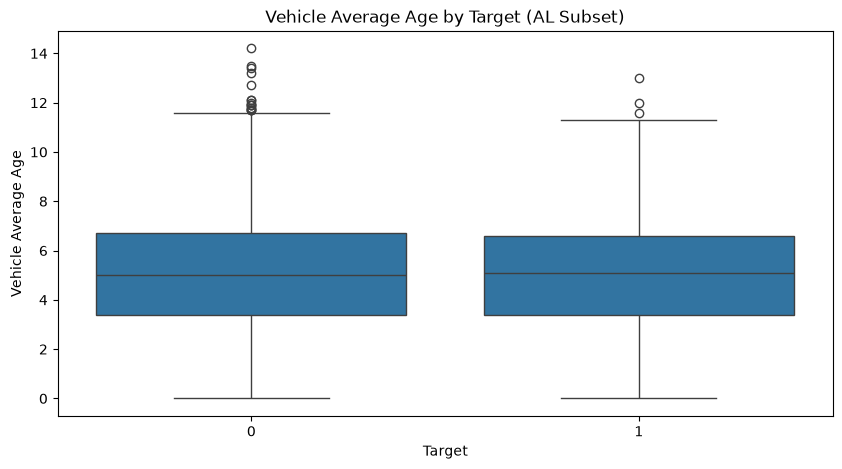

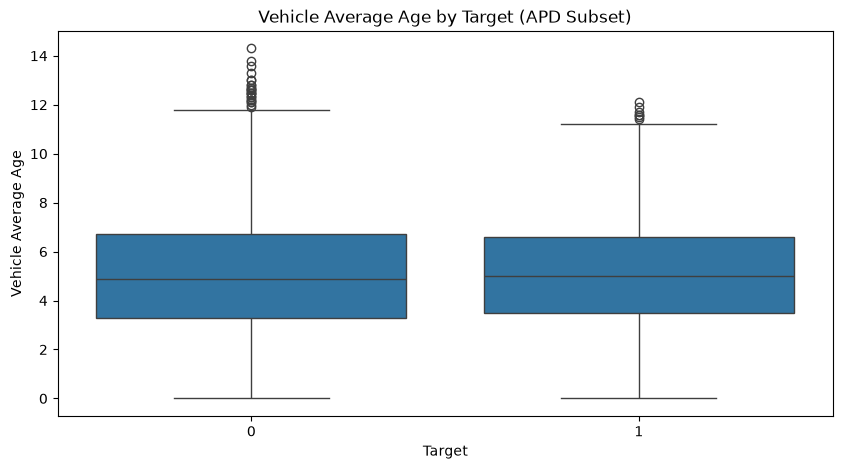

In [17]:
# boxplot for vehicle_avg_age based on target variable for AL subset
plot_boxplot(train_al, 'target', 'vehicle_avg_age', 'Vehicle Average Age by Target (AL Subset)', 'Target', 'Vehicle Average Age')

# boxplot for vehicle_avg_age based on target variable for APD subset
plot_boxplot(train_apd, 'target', 'vehicle_avg_age', 'Vehicle Average Age by Target (APD Subset)', 'Target', 'Vehicle Average Age')

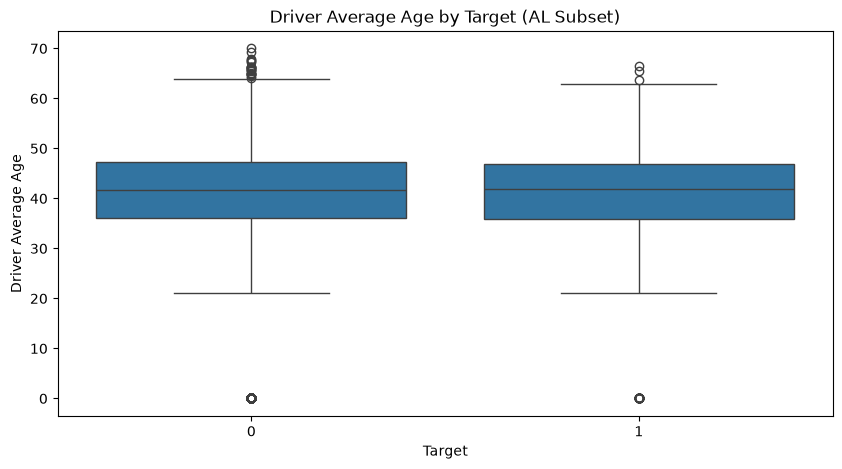

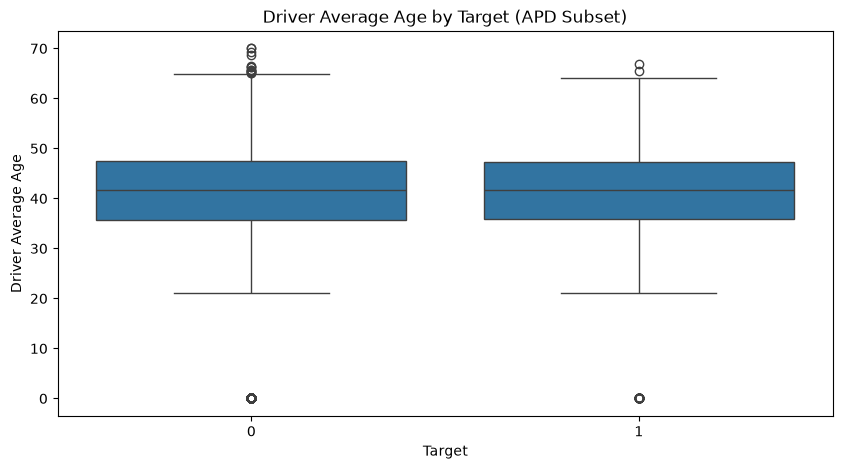

In [18]:
# boxplot for driver_avg_age based on target variable for AL subset
plot_boxplot(train_al, 'target', 'driver_avg_age', 'Driver Average Age by Target (AL Subset)', 'Target', 'Driver Average Age')

# boxplot for driver_avg_age based on target variable for APD subset
plot_boxplot(train_apd, 'target', 'driver_avg_age', 'Driver Average Age by Target (APD Subset)', 'Target', 'Driver Average Age')

We can see that some policies in both coverages have average drivers age = 0, which is not physically possible.

In [19]:
# check how many rows have driver_avg_age = 0 in each subset
print(f"Number of rows with driver_avg_age = 0 in AL subset: {len(train_al[train_al['driver_avg_age'] == 0])}")
print(f"Number of rows with driver_avg_age = 0 in APD subset: {len(train_apd[train_apd['driver_avg_age'] == 0])}")

Number of rows with driver_avg_age = 0 in AL subset: 295
Number of rows with driver_avg_age = 0 in APD subset: 308


As in both subsets the number of rows is around 300 we can not just delete those rows, instead it is better to replace those values with median age by business type.

In [20]:
def handle_zero_driver_age(df):
    df = df.copy()

    valid_ages = df[df['driver_avg_age'] > 0]

    # Calculate median age by business type
    median_by_business = valid_ages.groupby('business_type')['driver_avg_age'].median().to_dict()
    
    # Calculate global median age as a fallback
    global_median_age = valid_ages['driver_avg_age'].median()
    
    # Impute 0 values with the business median, falling back to the global median
    df['driver_avg_age'] = np.where(
        df['driver_avg_age'] == 0,
        df['business_type'].map(median_by_business).fillna(global_median_age),
        df['driver_avg_age']
    )
    
    return df

In [21]:
train_al = handle_zero_driver_age(train_al)
train_apd = handle_zero_driver_age(train_apd)

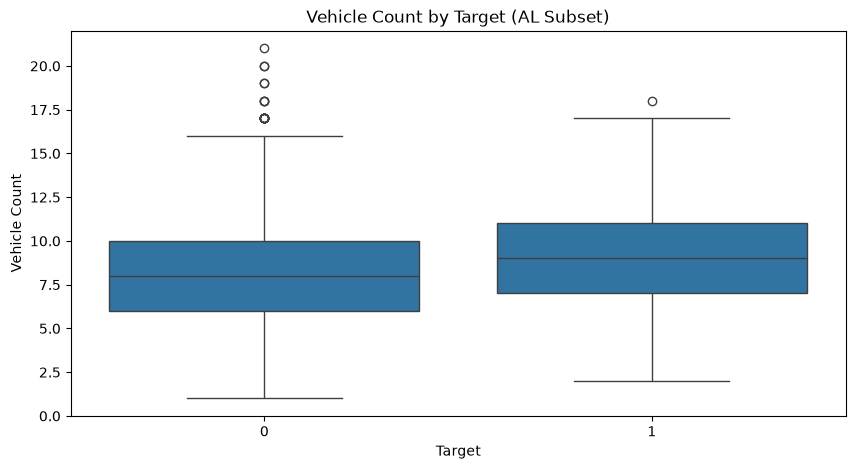

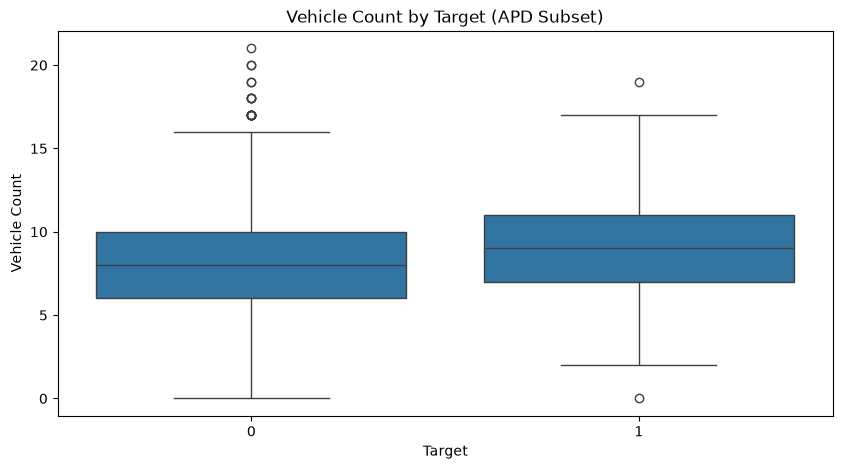

In [22]:
# boxplot for vehicle_count based on target variable for AL subset
plot_boxplot(train_al, 'target', 'vehicle_count', 'Vehicle Count by Target (AL Subset)', 'Target', 'Vehicle Count')

# boxplot for vehicle_count based on target variable for APD subset
plot_boxplot(train_apd, 'target', 'vehicle_count', 'Vehicle Count by Target (APD Subset)', 'Target', 'Vehicle Count')

In commercial insurance, a business can purchase an Auto Liability (AL) policy even if they own zero vehicles. It protects a business if an employee drives their own personal car for work errands (like a delivery driver or salesperson) and gets into an accident. However, a business should never have a vehicle_count = 0 on an Auto Physical Damage (APD) line, because APD strictly insures the physical body of cars owned by the business.

In [23]:
# check if there are any rows with vehicle count = 0 that has zero drivers
train_apd[(train_apd['vehicle_count'] == 0) & (train_apd['driver_count'] == 0)]

,policy_id,insured_id,snapshot_date,policy_effective_date,policy_expiration_date,coverage_type,vehicle_count,vehicle_avg_age,driver_count,driver_avg_age,...,has_safety_program,num_heavy_vehicles,late_payment_count,claim_count,total_loss_amount,first_claim_reported_date,claim_paid_amount_current_period,claim_status_current_period,days_to_first_claim_report,target


In [24]:
# check how many rows have vehicle_count = 0
train_apd[train_apd['vehicle_count'] == 0].shape[0]

5

As it is only 5 rows we can delete them from the dataset.

In [25]:
# delete rows with vehicle_count = 0
train_apd = train_apd[train_apd['vehicle_count'] > 0].copy()

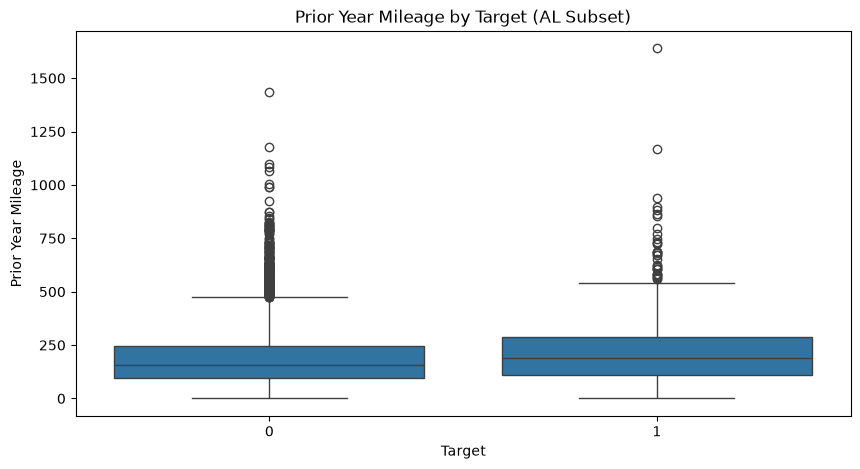

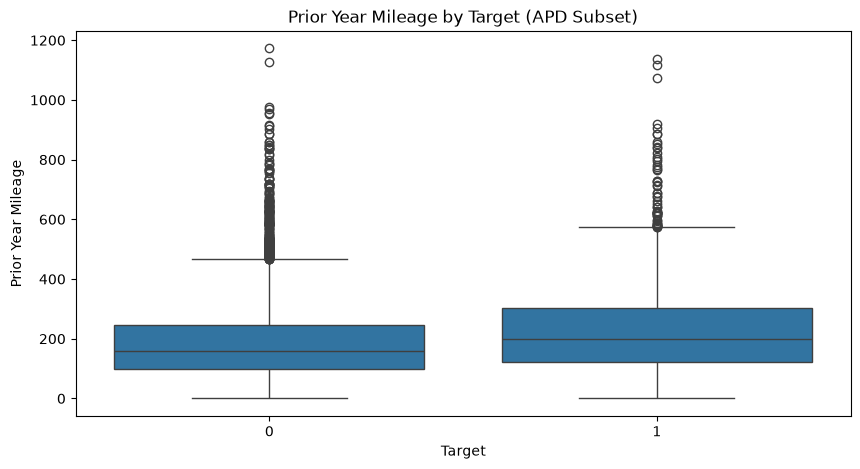

In [26]:
# boxplot for prior_year_mileage_000 based on target variable for AL subset
plot_boxplot(train_al, 'target', 'prior_year_mileage_000', 'Prior Year Mileage by Target (AL Subset)', 'Target', 'Prior Year Mileage')

# boxplot for prior_year_mileage_000 based on target variable for APD subset
plot_boxplot(train_apd, 'target', 'prior_year_mileage_000', 'Prior Year Mileage by Target (APD Subset)', 'Target', 'Prior Year Mileage')

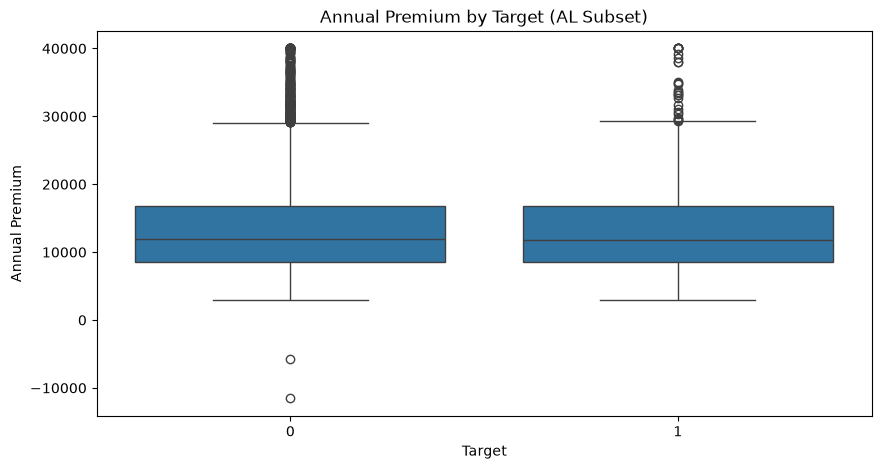

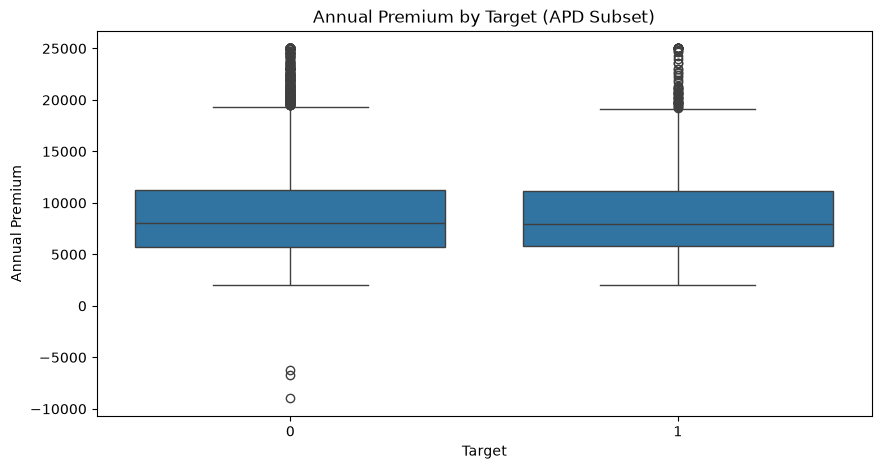

In [27]:
# boxplot for annual_premium based on target variable for AL subset
plot_boxplot(train_al, 'target', 'annual_premium', 'Annual Premium by Target (AL Subset)', 'Target', 'Annual Premium')

# boxplot for annual_premium based on target variable for APD subset
plot_boxplot(train_apd, 'target', 'annual_premium', 'Annual Premium by Target (APD Subset)', 'Target', 'Annual Premium')

In [28]:
# check rows with annual premium less or equal to 0
train[train['annual_premium'] <= 0]

,policy_id,insured_id,snapshot_date,policy_effective_date,policy_expiration_date,coverage_type,vehicle_count,vehicle_avg_age,driver_count,driver_avg_age,...,has_safety_program,num_heavy_vehicles,late_payment_count,claim_count,total_loss_amount,first_claim_reported_date,claim_paid_amount_current_period,claim_status_current_period,days_to_first_claim_report,target
2571,POL-003964,INS-01029,2021-02-18,2020-09-12,2021-09-12,APD,8,9.5,6,48.0,...,0,1,0.0,0,0.0,NaT,0.0,No Claim,0.0,0
5362,POL-003525,INS-03171,2020-11-14,2020-10-30,2021-10-30,APD,6,8.3,4,32.5,...,0,1,0.0,0,0.0,NaT,0.0,No Claim,0.0,0
10139,POL-005629,INS-01603,2021-05-01,2021-01-14,2022-01-14,APD,8,7.2,5,47.2,...,0,3,0.0,0,0.0,NaT,0.0,No Claim,0.0,0
10327,POL-008752,INS-03229,2021-10-24,2021-06-29,2022-06-29,AL,13,5.6,10,38.5,...,1,3,1.0,0,0.0,NaT,0.0,No Claim,0.0,0
14455,POL-013297,INS-02261,2021-08-28,2021-07-17,2022-07-17,AL,15,5.4,4,45.5,...,1,3,0.0,0,0.0,NaT,0.0,No Claim,0.0,0


In a static policy snapshot, negative premiums are anomalies, because there are only 5 rows (3 in APD and 2 in AL we delete them).

In [29]:
# filtering out rows with annual premium less than or equal to 0
train_al = train_al[train_al['annual_premium'] > 0].copy()
train_apd = train_apd[train_apd['annual_premium'] > 0].copy()

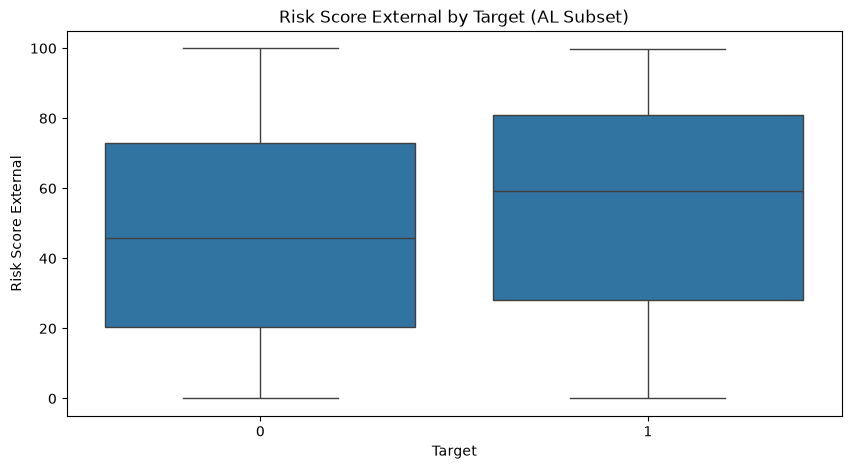

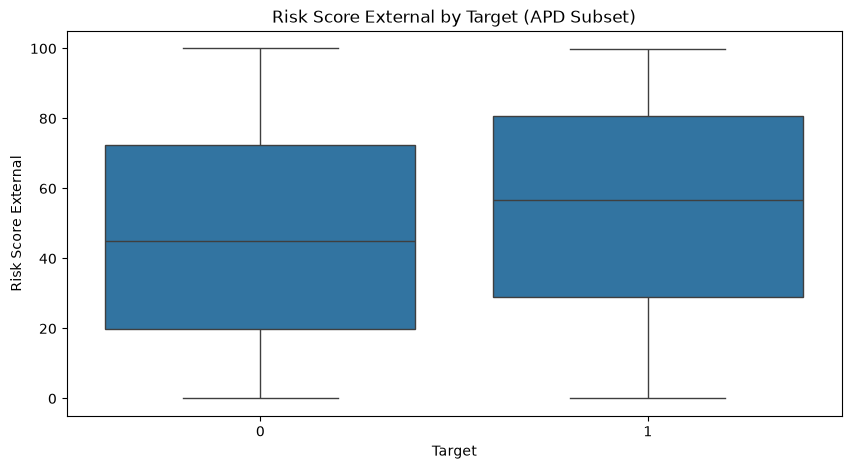

In [30]:
# boxplot for risk_score_external based on target variable for AL subset
plot_boxplot(train_al, 'target', 'risk_score_external', 'Risk Score External by Target (AL Subset)', 'Target', 'Risk Score External')

# boxplot for risk_score_external based on target variable for APD subset
plot_boxplot(train_apd, 'target', 'risk_score_external', 'Risk Score External by Target (APD Subset)', 'Target', 'Risk Score External')

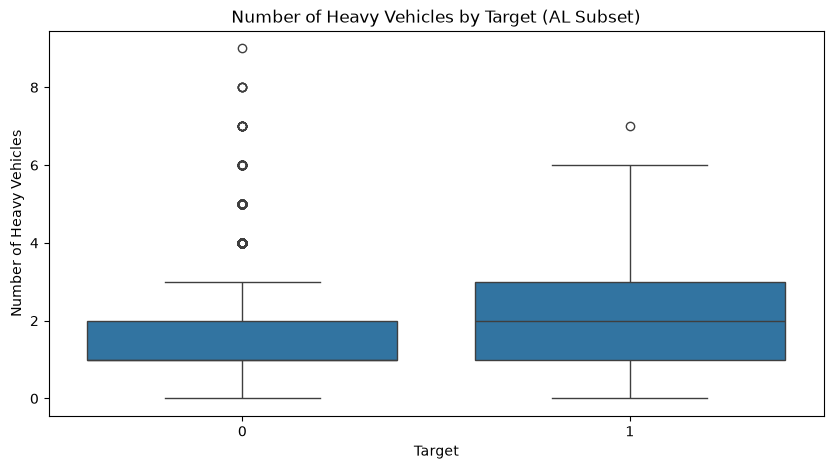

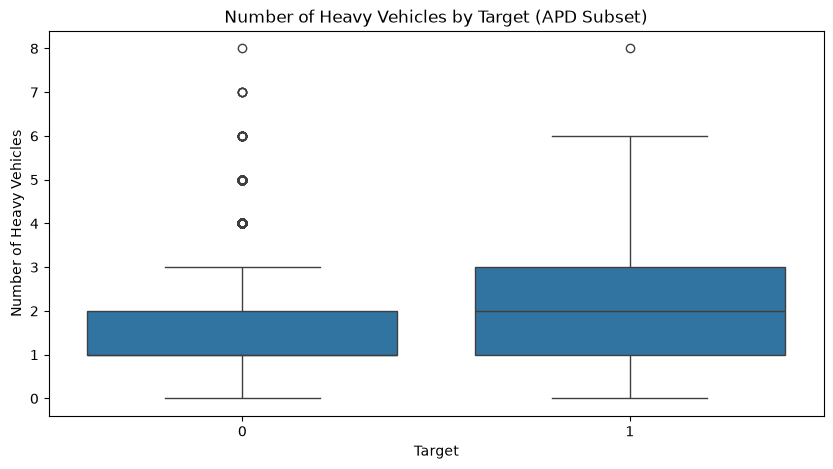

In [31]:
# boxplot for num_heavy_vehicles based on target variable for AL subset
plot_boxplot(train_al, 'target', 'num_heavy_vehicles', 'Number of Heavy Vehicles by Target (AL Subset)', 'Target', 'Number of Heavy Vehicles')

# boxplot for num_heavy_vehicles based on target variable for APD subset
plot_boxplot(train_apd, 'target', 'num_heavy_vehicles', 'Number of Heavy Vehicles by Target (APD Subset)', 'Target', 'Number of Heavy Vehicles')

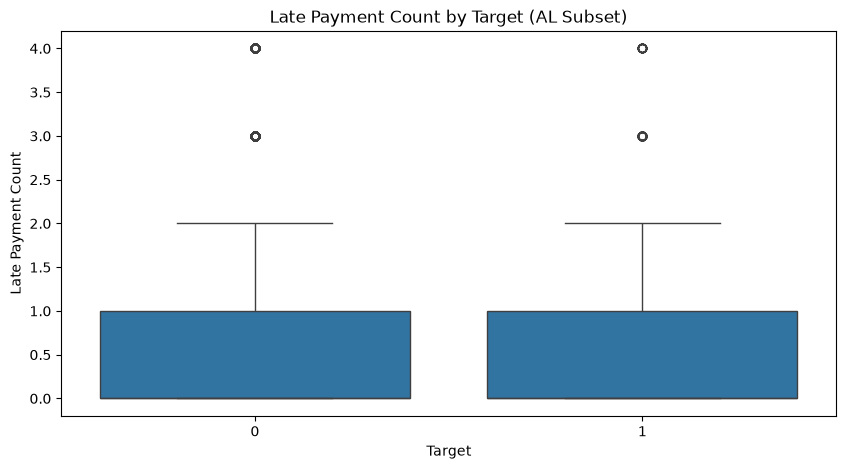

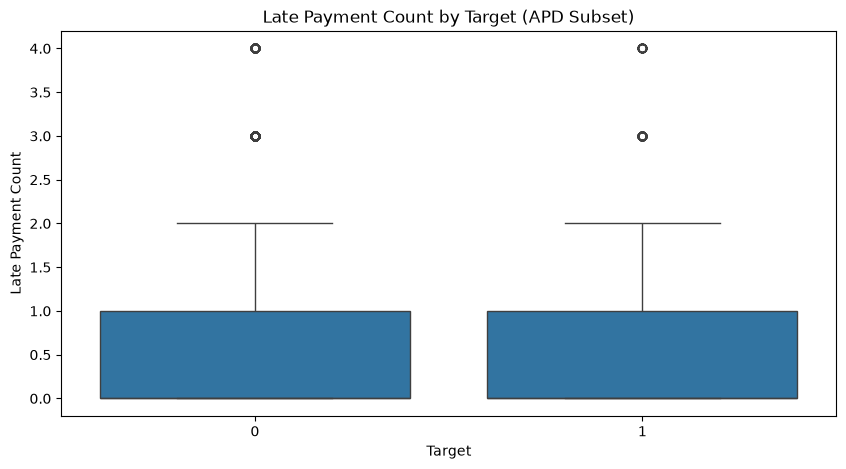

In [32]:
# boxplot for late_payment_count based on target variable for AL subset
plot_boxplot(train_al, 'target', 'late_payment_count', 'Late Payment Count by Target (AL Subset)', 'Target', 'Late Payment Count')

# boxplot for late_payment_count based on target variable for APD subset
plot_boxplot(train_apd, 'target', 'late_payment_count', 'Late Payment Count by Target (APD Subset)', 'Target', 'Late Payment Count')

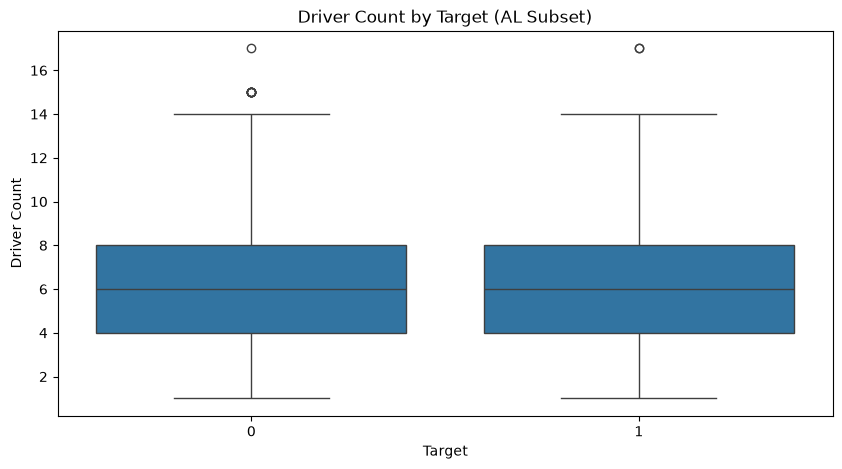

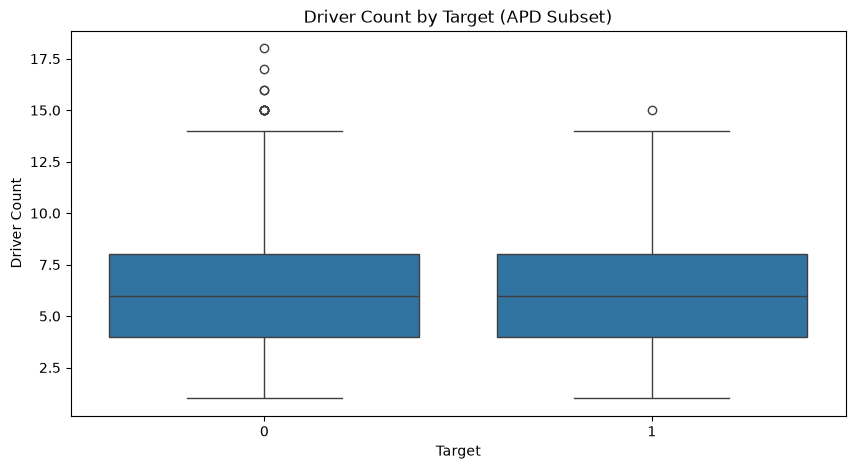

In [33]:
# boxplot for driver_count based on target variable for AL subset
plot_boxplot(train_al, 'target', 'driver_count', 'Driver Count by Target (AL Subset)', 'Target', 'Driver Count')

# boxplot for driver_count based on target variable for APD subset
plot_boxplot(train_apd, 'target', 'driver_count', 'Driver Count by Target (APD Subset)', 'Target', 'Driver Count')

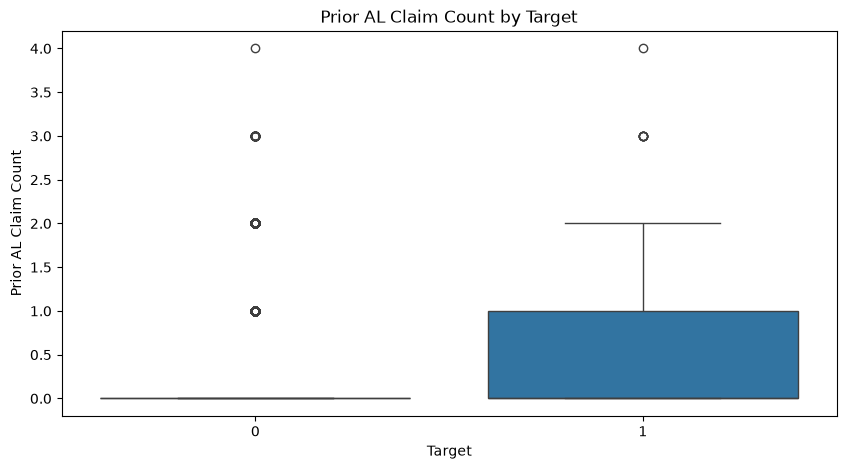

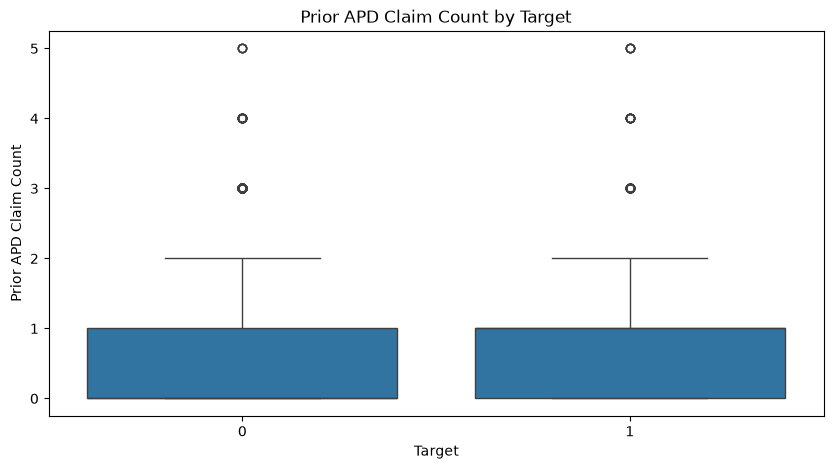

In [34]:
# boxplot for prior_al_claim_count based on target variable for APD subset
plot_boxplot(train_apd, 'target', 'prior_al_claim_count', 'Prior AL Claim Count by Target', 'Target', 'Prior AL Claim Count')

# boxplot for prior_apd_claim_count based on target variable for APD subset
plot_boxplot(train_apd, 'target', 'prior_apd_claim_count', 'Prior APD Claim Count by Target', 'Target', 'Prior APD Claim Count')

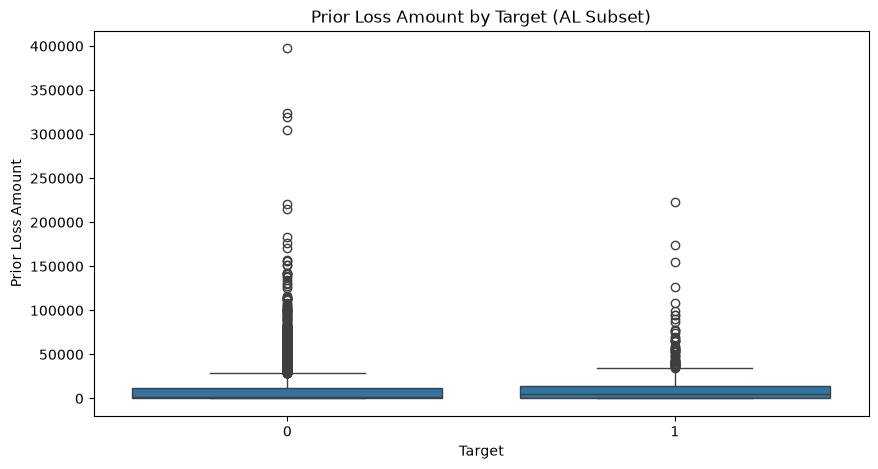

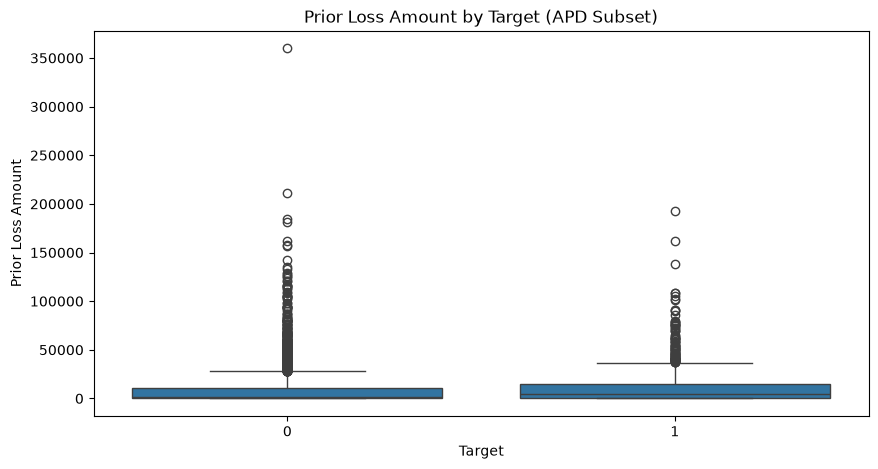

In [35]:
# boxplot for prior_loss_amount based on target variable for AL subset
plot_boxplot(train_al, 'target', 'prior_loss_amount', 'Prior Loss Amount by Target (AL Subset)', 'Target', 'Prior Loss Amount')

# boxplot for prior_loss_amount based on target variable for APD subset
plot_boxplot(train_apd, 'target', 'prior_loss_amount', 'Prior Loss Amount by Target (APD Subset)', 'Target', 'Prior Loss Amount')

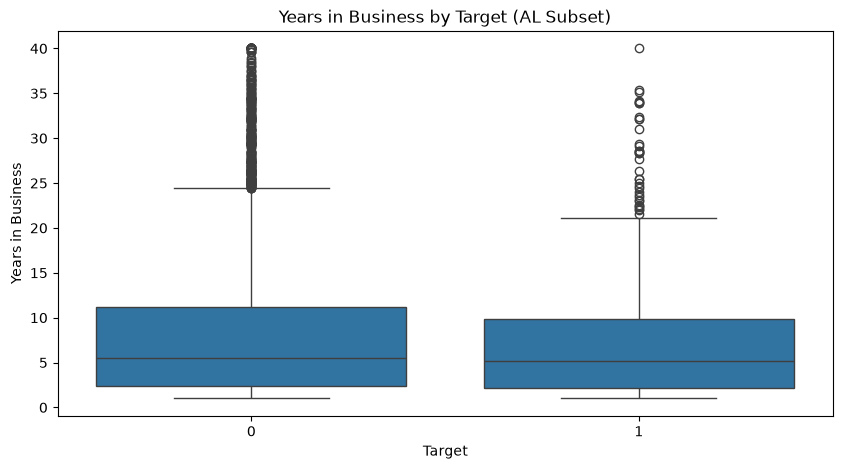

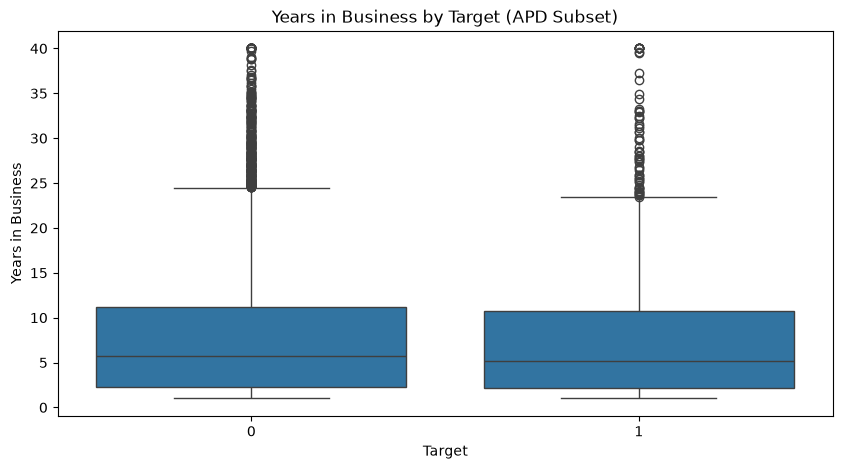

In [36]:
# boxplot for years_in_business based on target variable for AL subset
plot_boxplot(train_al, 'target', 'years_in_business', 'Years in Business by Target (AL Subset)', 'Target', 'Years in Business')

# boxplot for years_in_business based on target variable for APD subset
plot_boxplot(train_apd, 'target', 'years_in_business', 'Years in Business by Target (APD Subset)', 'Target', 'Years in Business')

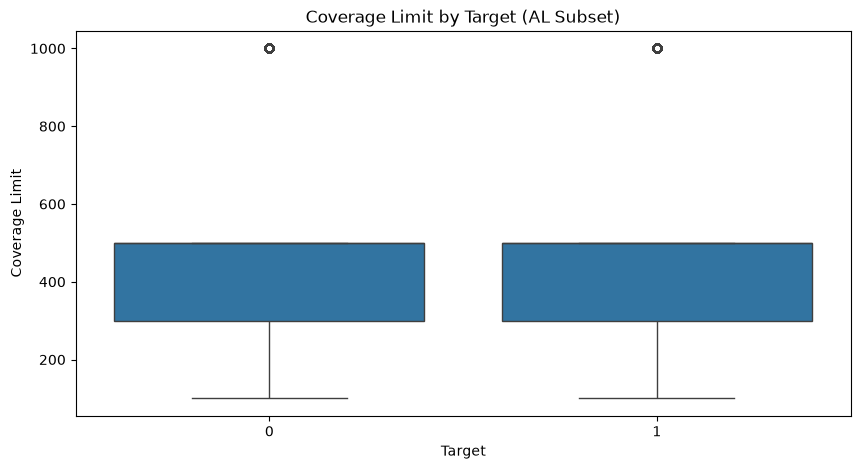

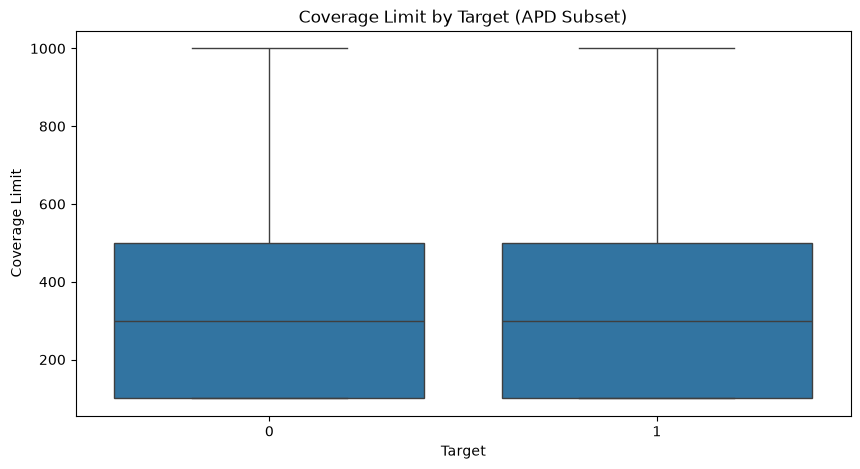

In [37]:
# boxplot for coverage_limit based on target variable for AL subset
plot_boxplot(train_al, 'target', 'coverage_limit_000', 'Coverage Limit by Target (AL Subset)', 'Target', 'Coverage Limit')

# boxplot for coverage_limit based on target variable for APD subset
plot_boxplot(train_apd, 'target', 'coverage_limit_000', 'Coverage Limit by Target (APD Subset)', 'Target', 'Coverage Limit')

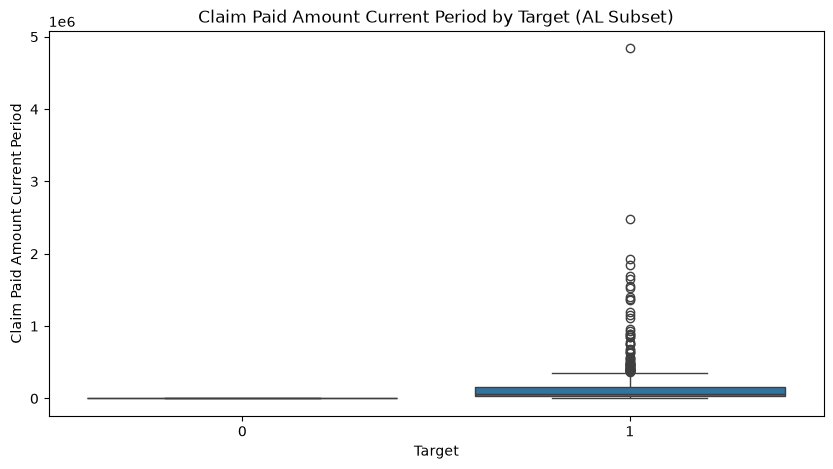

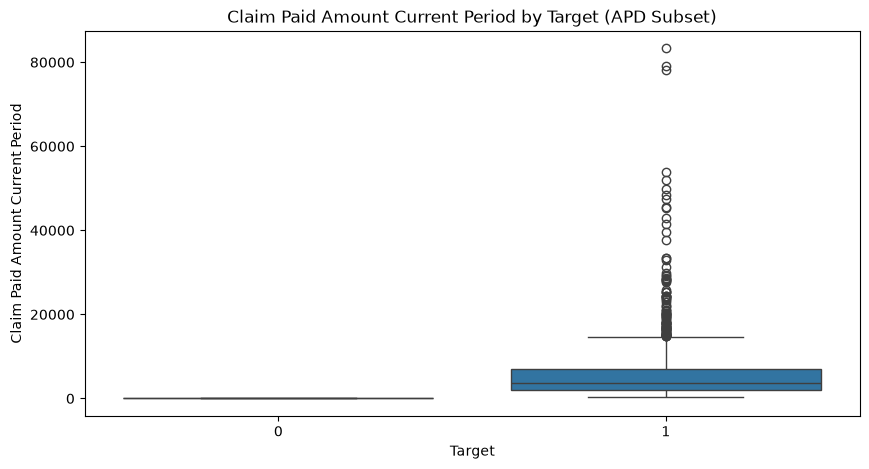

In [38]:
# boxplot for claim_paid_amount_current_period based on target variable for AL subset
plot_boxplot(train_al, 'target', 'claim_paid_amount_current_period', 'Claim Paid Amount Current Period by Target (AL Subset)', 'Target', 'Claim Paid Amount Current Period')

# boxplot for claim_paid_amount_current_period based on target variable for APD subset
plot_boxplot(train_apd, 'target', 'claim_paid_amount_current_period', 'Claim Paid Amount Current Period by Target (APD Subset)', 'Target', 'Claim Paid Amount Current Period')

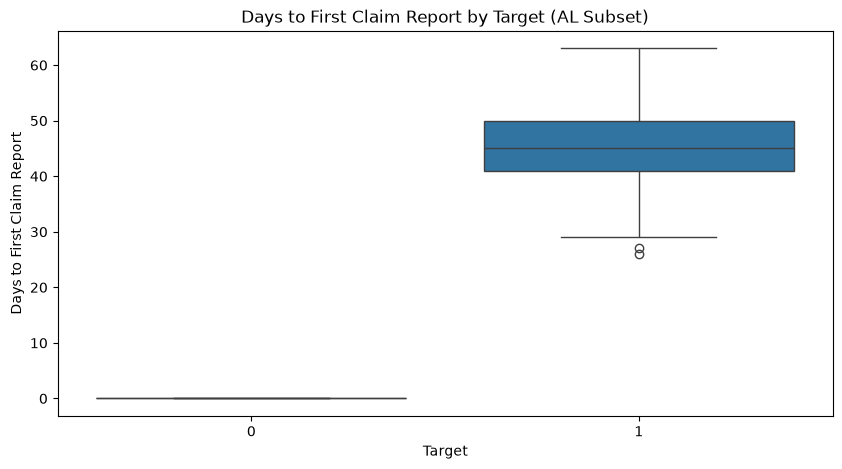

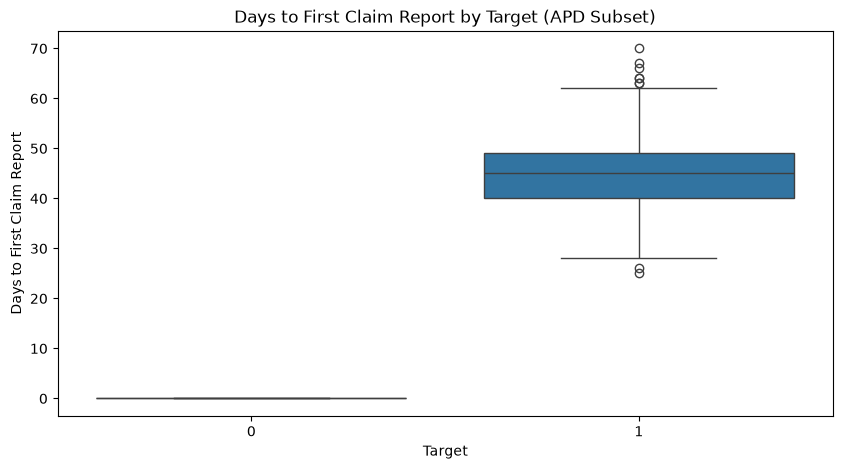

In [39]:
# boxplot for days_to_first_claim_report based on target variable for AL subset
plot_boxplot(train_al, 'target', 'days_to_first_claim_report', 'Days to First Claim Report by Target (AL Subset)', 'Target', 'Days to First Claim Report')

# boxplot for days_to_first_claim_report based on target variable for APD subset
plot_boxplot(train_apd, 'target', 'days_to_first_claim_report', 'Days to First Claim Report by Target (APD Subset)', 'Target', 'Days to First Claim Report')

## Mutual Information

Most of univariate boxplots showed overlapping distributions for several features, because of that we can check how they affect the target variable using mutual information.

In [40]:
num_cols = [col for col in train.select_dtypes(include=[np.number]).columns if col not in ["target", "claim_count", "has_safety_program", "deductible"]]
discrete_cols = ["vehicle_count", "driver_count", "prior_apd_claim_count", "prior_al_claim_count", "late_payment_count", "num_heavy_vehicles", "coverage_limit_000",
                 "days_to_first_claim_report"]
discrete_mask = [col in discrete_cols for col in num_cols]

mi_scores_al = mutual_info_classif(train_al[num_cols], train_al['target'], discrete_features=discrete_mask, random_state=42)
mi_series_al = pd.Series(mi_scores_al, index=num_cols).sort_values(ascending=False)

mi_series_al

total_loss_amount                   0.304397
claim_paid_amount_current_period    0.304397
days_to_first_claim_report          0.304330
vehicle_count                       0.008540
num_heavy_vehicles                  0.003795
risk_score_external                 0.002750
prior_year_mileage_000              0.002358
prior_al_claim_count                0.002245
driver_count                        0.001208
prior_apd_claim_count               0.001109
vehicle_avg_age                     0.000637
late_payment_count                  0.000551
coverage_limit_000                  0.000380
prior_loss_amount                   0.000099
years_in_business                   0.000000
driver_avg_age                      0.000000
annual_premium                      0.000000
dtype: float64

Based on mutual information and boxplots we will omit driver_avg_age and annual_premium form feautures when modeling.

In [41]:
mi_scores_apd = mutual_info_classif(train_apd[num_cols], train_apd['target'], discrete_features=discrete_mask, random_state=42)
mi_series_apd = pd.Series(mi_scores_apd, index=num_cols).sort_values(ascending=False)

mi_series_apd

total_loss_amount                   0.433339
claim_paid_amount_current_period    0.433339
days_to_first_claim_report          0.433273
vehicle_count                       0.015298
annual_premium                      0.009545
prior_year_mileage_000              0.005316
prior_apd_claim_count               0.004987
prior_loss_amount                   0.004906
risk_score_external                 0.004400
driver_avg_age                      0.002754
num_heavy_vehicles                  0.002381
vehicle_avg_age                     0.002256
years_in_business                   0.001571
late_payment_count                  0.000613
driver_count                        0.000604
prior_al_claim_count                0.000402
coverage_limit_000                  0.000137
dtype: float64

Based on mutual information we use all features for APD coverage as they all have at least some impact on our target variable.

# Plot for categorical columns

For categorical columns we plot the calim frequency for each category, to spot if any category has higher percentage of claims compared to others.

In [42]:
def plot_claim_frequency_by_category(data, category_col, title):
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(10, 5))
    ax = sns.barplot(
        x=category_col, 
        y="target", 
        data=data, 
        errorbar="ci" 
    )
    
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel(category_col.replace('_', ' ').title(), fontsize=10)
    plt.ylabel("Percentage of Policies with Claims (%)", fontsize=12)
    plt.show()

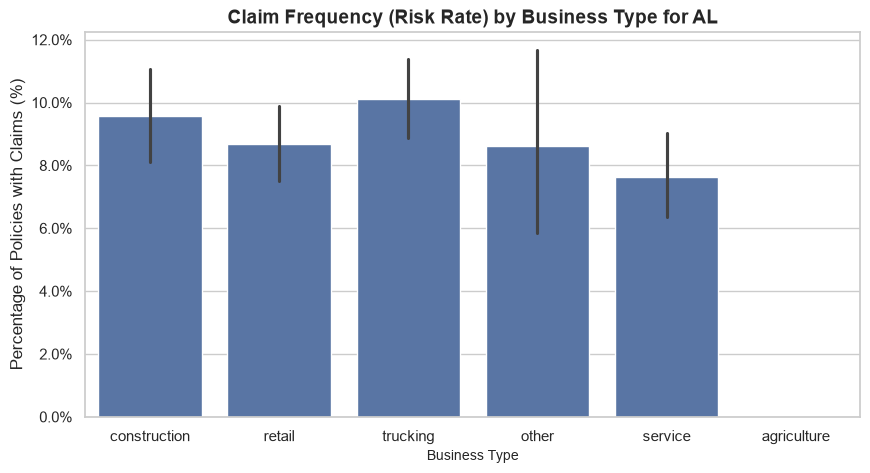

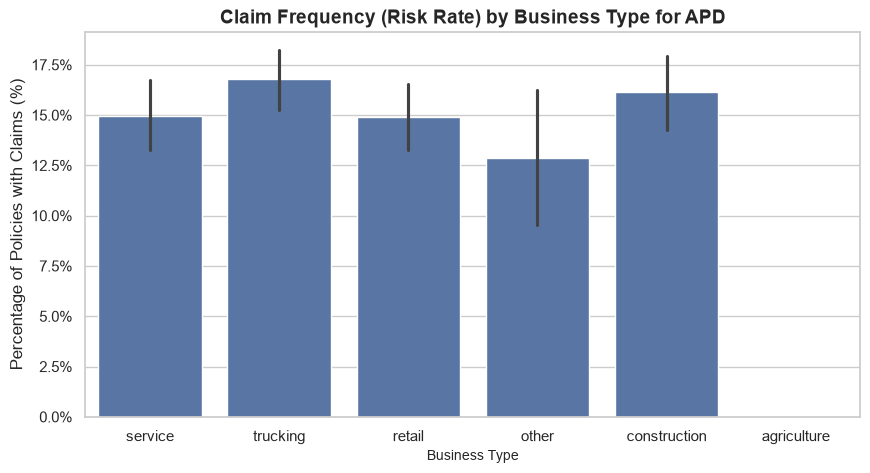

In [43]:
# barplot for claim frequency by business type for AL subset
plot_claim_frequency_by_category(train_al, "business_type", "Claim Frequency (Risk Rate) by Business Type for AL")

# barplot for claim frequency by business type for APD subset
plot_claim_frequency_by_category(train_apd, "business_type", "Claim Frequency (Risk Rate) by Business Type for APD")

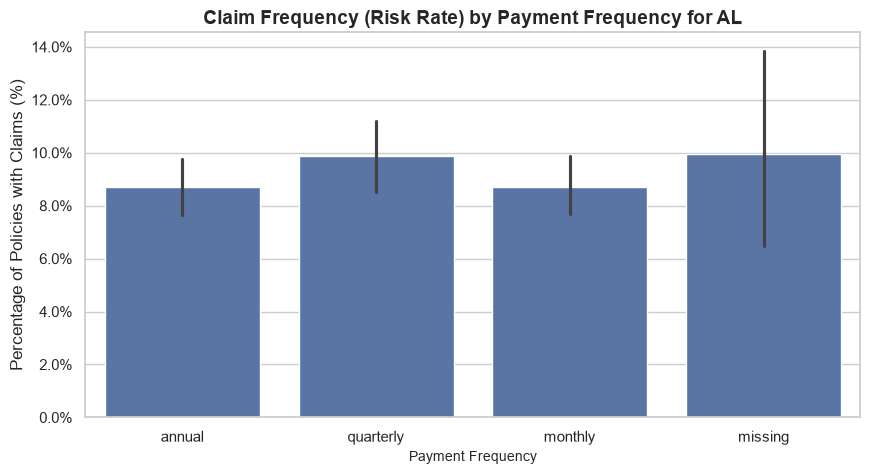

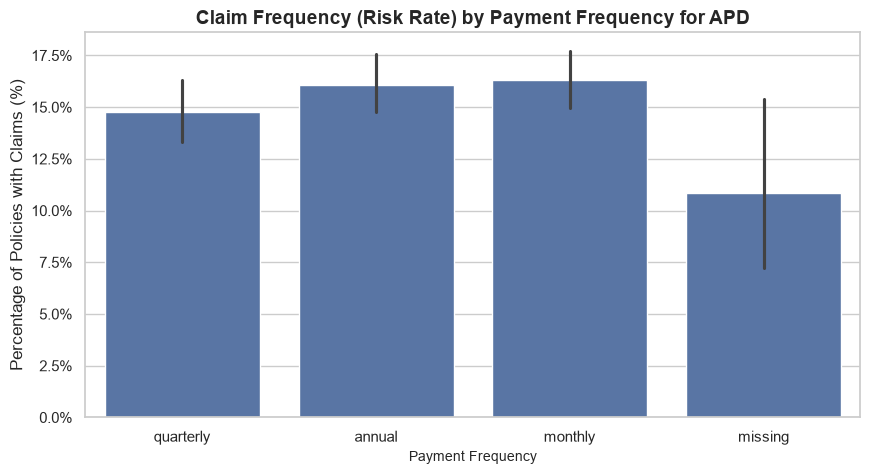

In [44]:
# barplot for claim frequency by payment frequency for AL subset
plot_claim_frequency_by_category(train_al, "payment_frequency", "Claim Frequency (Risk Rate) by Payment Frequency for AL")

# barplot for claim frequency by payment frequency for APD subset
plot_claim_frequency_by_category(train_apd, "payment_frequency", "Claim Frequency (Risk Rate) by Payment Frequency for APD")

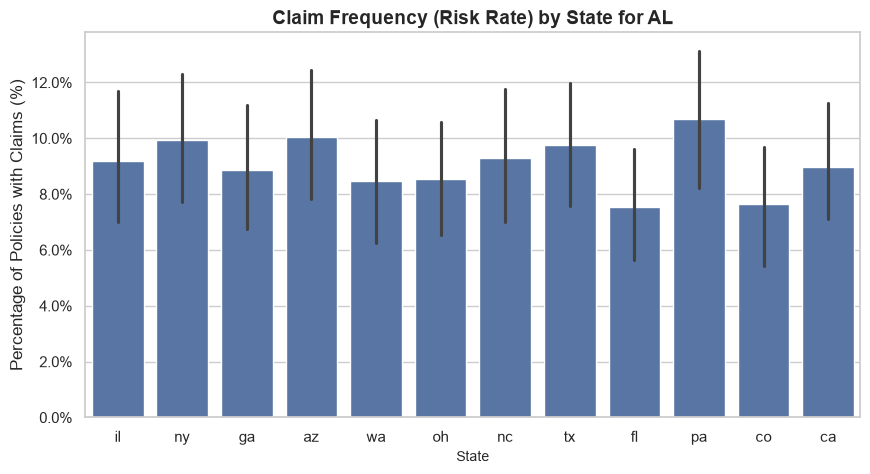

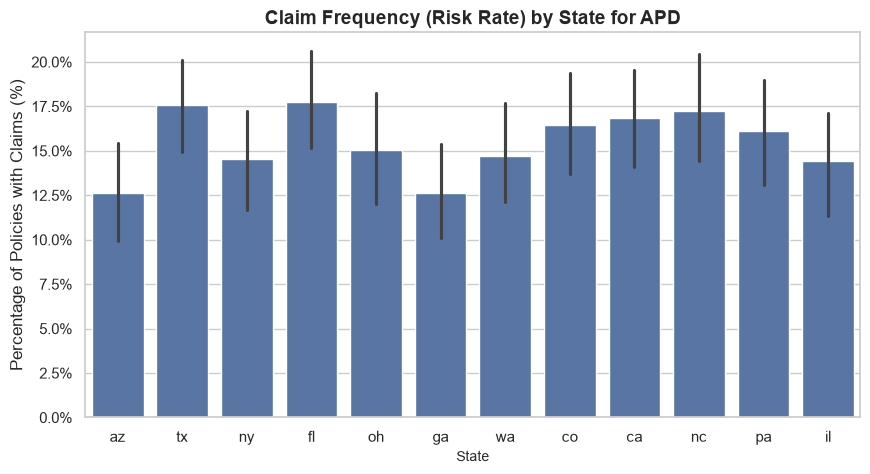

In [45]:
# barplot for claim frequency by state for AL subset
plot_claim_frequency_by_category(train_al, "state", "Claim Frequency (Risk Rate) by State for AL")

# barplot for claim frequency by state for APD subset
plot_claim_frequency_by_category(train_apd, "state", "Claim Frequency (Risk Rate) by State for APD")

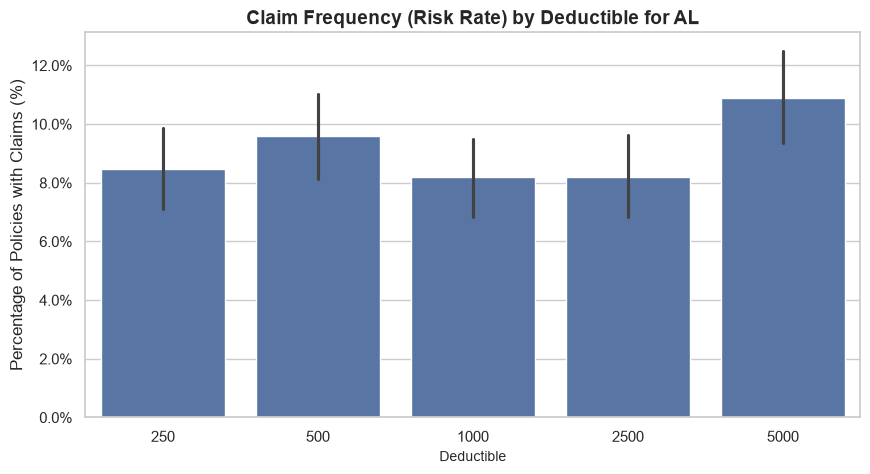

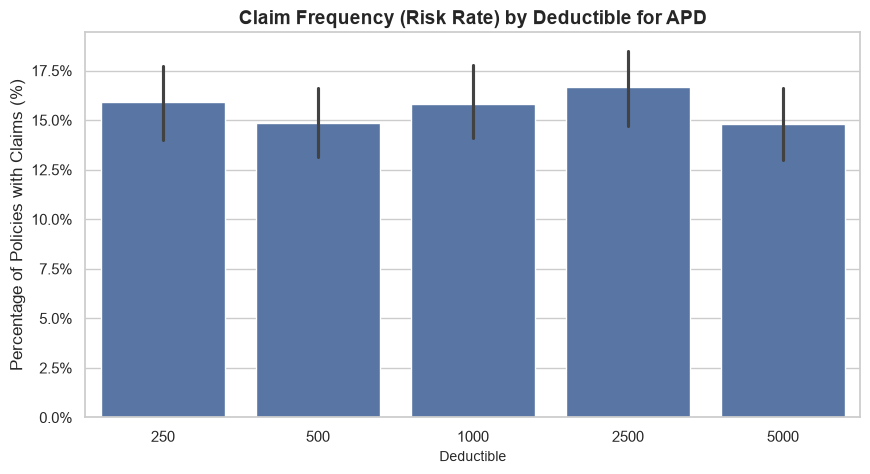

In [46]:
# barplot for deductible by claim frequency for AL subset
plot_claim_frequency_by_category(train_al, "deductible", "Claim Frequency (Risk Rate) by Deductible for AL")

# barplot for deductible by claim frequency for APD subset
plot_claim_frequency_by_category(train_apd, "deductible", "Claim Frequency (Risk Rate) by Deductible for APD")

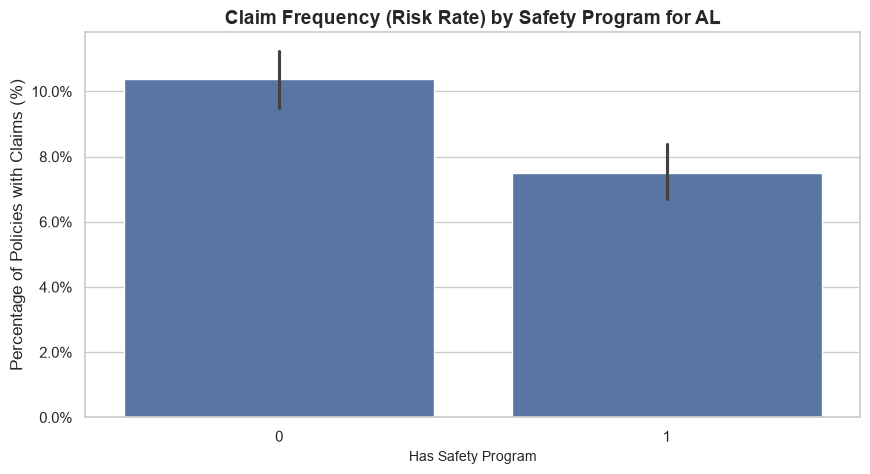

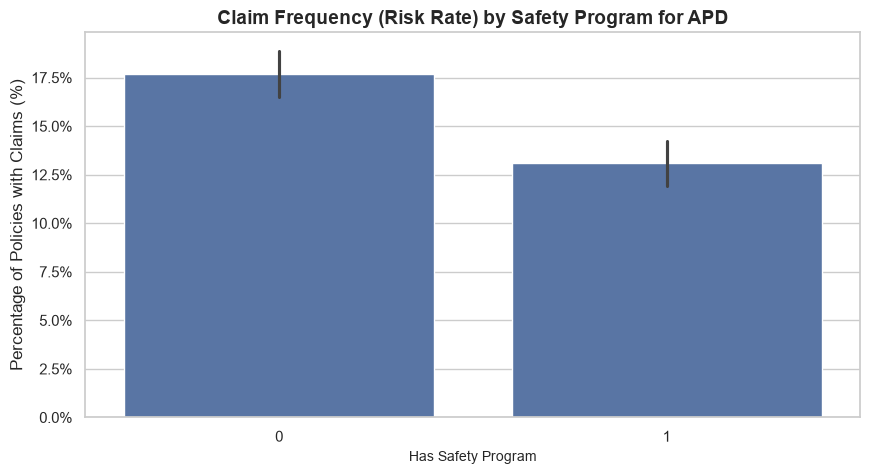

In [47]:
# barplot for has_safety_program by claim frequency for AL subset
plot_claim_frequency_by_category(train_al, "has_safety_program", "Claim Frequency (Risk Rate) by Safety Program for AL")

# barplot for has_safety_program by claim frequency for APD subset
plot_claim_frequency_by_category(train_apd, "has_safety_program", "Claim Frequency (Risk Rate) by Safety Program for APD")

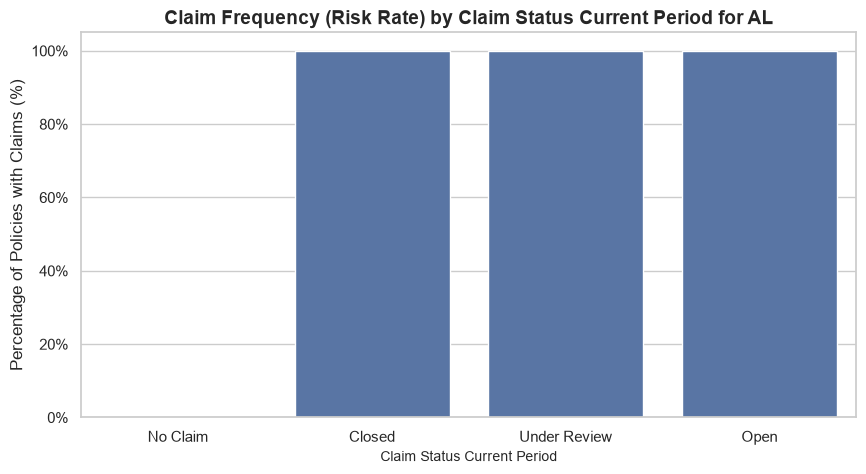

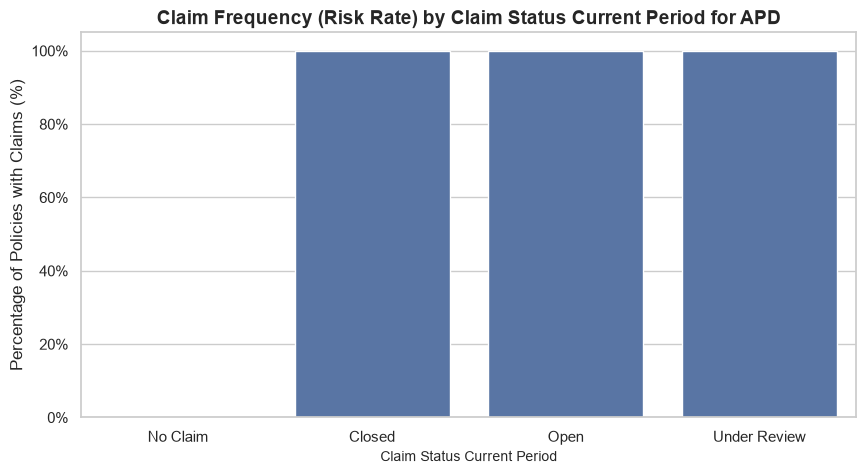

In [48]:
# barplot for claim_status_current_period by claim frequency for AL subset
plot_claim_frequency_by_category(train_al, "claim_status_current_period", "Claim Frequency (Risk Rate) by Claim Status Current Period for AL")

# barplot for claim_status_current_period by claim frequency for APD subset
plot_claim_frequency_by_category(train_apd, "claim_status_current_period", "Claim Frequency (Risk Rate) by Claim Status Current Period for APD")

 We will exclude this column because it introduces data leakage by providing post-inception claim information. Including it would cause the model to rely on future outcomes, making it useless when evaluating new applicants.

In [49]:
train_al = train_al.drop(columns=['claim_status_current_period']).copy()
train_apd = train_apd.drop(columns=['claim_status_current_period']).copy()

# Multicolinearity

Some ML algorithms have problems with multicolinearity (e.g. logistic regression), because of that we check if any columns have high colinearity between each other using corelation matrix and VIF.

In [50]:
# display multicolinearity using heatmap in both AL and APD subsets
def plot_correlation_heatmap(data, title):
    plt.figure(figsize=(12, 8))
    correlation_matrix = data.corr()
    sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
    plt.title(title)
    plt.show()

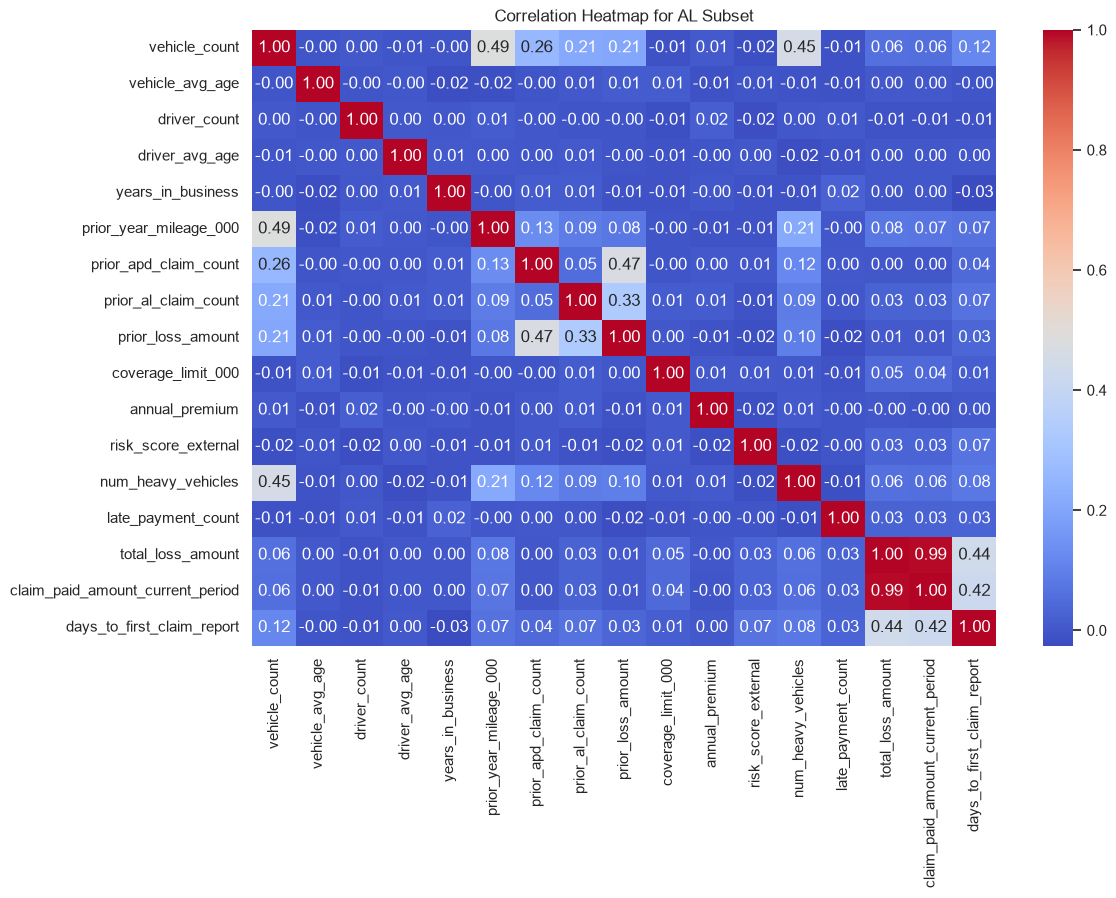

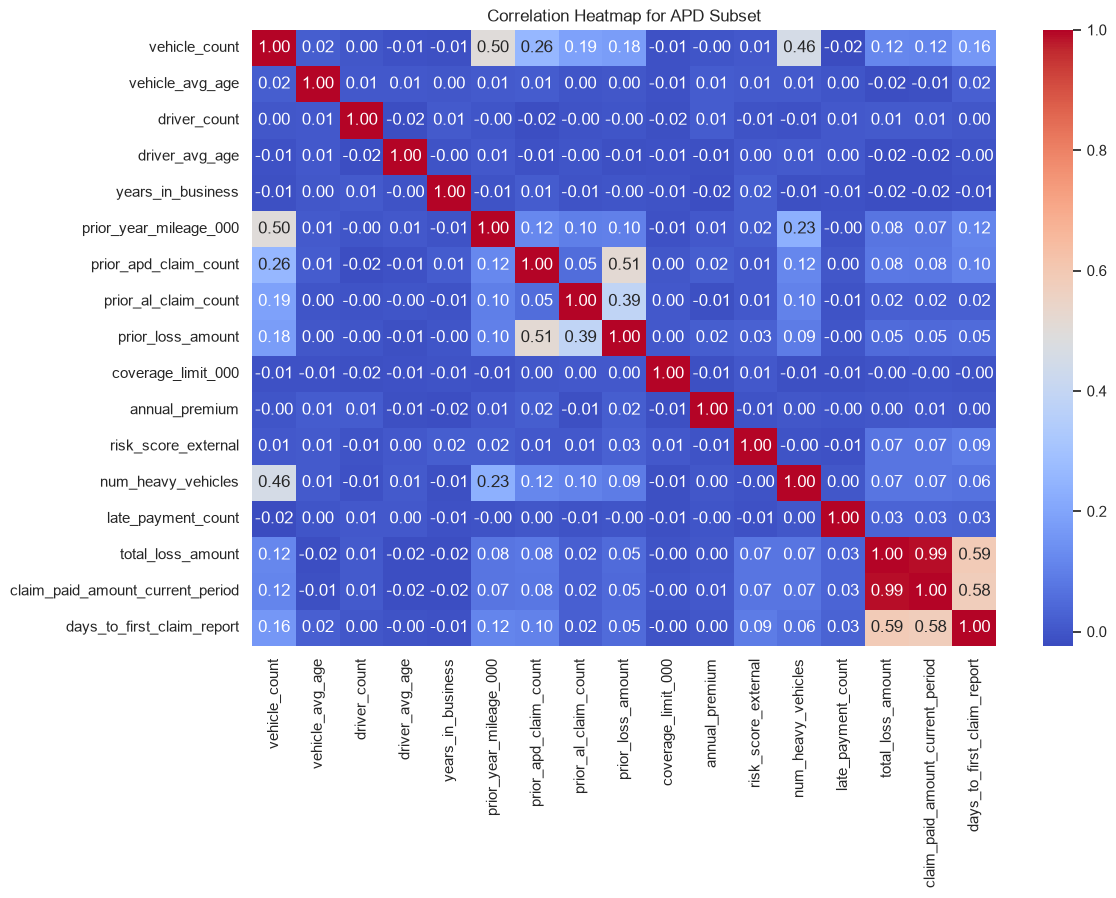

In [51]:
plot_correlation_heatmap(train_al[num_cols], "Correlation Heatmap for AL Subset")
plot_correlation_heatmap(train_apd[num_cols], "Correlation Heatmap for APD Subset")

In [52]:
def calculate_vif(data, features):
    vif_data = pd.DataFrame()
    vif_data["Variable"] = features
    vif_data["VIF"] = [variance_inflation_factor(data[features].values, i) for i in range(len(features))]
    return vif_data

In [53]:
# check VIF in both AL and APD subsets
vif_al = calculate_vif(train_al, num_cols)
vif_apd = calculate_vif(train_apd, num_cols)

In [54]:
vif_al, vif_apd

(                            Variable         VIF
 0                      vehicle_count   14.272001
 1                    vehicle_avg_age    4.886975
 2                       driver_count    6.391159
 3                     driver_avg_age   15.591253
 4                  years_in_business    2.062474
 5             prior_year_mileage_000    3.741225
 6              prior_apd_claim_count    2.101800
 7               prior_al_claim_count    1.532469
 8                  prior_loss_amount    1.834713
 9                 coverage_limit_000    3.794009
 10                    annual_premium    4.616050
 11               risk_score_external    3.323454
 12                num_heavy_vehicles    3.301338
 13                late_payment_count    1.487489
 14                 total_loss_amount  105.514989
 15  claim_paid_amount_current_period  103.684658
 16        days_to_first_claim_report    1.406636,
                             Variable        VIF
 0                      vehicle_count  13.725410
 

Based on the VIF to prevnet multicolinearity we will omit total_loss_amount as a feature as this column is not present in the score dataset. <br>
Also we will omit driver_avg_age as based on boxplots it doesn't seem to have impact on the target variable.

In [55]:
train_al = train_al.drop(columns=["total_loss_amount", "driver_avg_age"]).copy()
train_apd = train_apd.drop(columns=["total_loss_amount", "driver_avg_age"]).copy()

In [56]:
# check VIF again to see if dropping total_loss_amount and driver_avg_age improved multicollinearity
num_cols = [col for col in num_cols if col not in ["total_loss_amount", "driver_avg_age", "has_safety_program"]]

vif_al = calculate_vif(train_al, num_cols)
vif_apd = calculate_vif(train_apd, num_cols)

vif_al, vif_apd

(                            Variable        VIF
 0                      vehicle_count  13.043396
 1                    vehicle_avg_age   4.510233
 2                       driver_count   5.689839
 3                  years_in_business   2.019117
 4             prior_year_mileage_000   3.735340
 5              prior_apd_claim_count   2.101758
 6               prior_al_claim_count   1.531894
 7                  prior_loss_amount   1.834671
 8                 coverage_limit_000   3.603404
 9                     annual_premium   4.325664
 10               risk_score_external   3.161648
 11                num_heavy_vehicles   3.300672
 12                late_payment_count   1.476117
 13  claim_paid_amount_current_period   1.245344
 14        days_to_first_claim_report   1.359494,
                             Variable        VIF
 0                      vehicle_count  12.613322
 1                    vehicle_avg_age   4.509718
 2                       driver_count   5.661833
 3                 